#### Transfer Learning using ResNet50 in PyTorch

###### Imports

In [16]:
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models,datasets
from matplotlib import pyplot as plt
import numpy as np
import os


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

###### Image Transformations

In [18]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.486],std=[0.229,0.224,0.225])
])

###### Load the dataset

In [19]:
data_dir = 'Datasets/Fruits_5_classes/Fruits_Classification'
train_dataset = datasets.ImageFolder(os.path.join(data_dir,'train'),transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir,'test'),transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset,batch_size=32,shuffle=False)

###### Getting the dataset info

In [20]:
def get_dataset_info(dataset):
    print(f'Number of classes: {len(dataset.classes)}')
    print(f'Class names: {dataset.classes}')
    print(f'Number of images: {len(dataset)}')
    class_counts = {cls:0 for cls in dataset.classes}
    for _,label in dataset.samples:
        class_counts[dataset.classes[label]] +=1
    print('Class distribution')
    for cls,count in class_counts.items():
        print(f'{cls} : {count}')

print('Training Dataset info')
get_dataset_info(train_dataset)
print('Validation Dataset info')
get_dataset_info(val_dataset)

Training Dataset info
Number of classes: 5
Class names: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Number of images: 9700
Class distribution
Apple : 1940
Banana : 1940
Grape : 1940
Mango : 1940
Strawberry : 1940
Validation Dataset info
Number of classes: 5
Class names: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Number of images: 100
Class distribution
Apple : 20
Banana : 20
Grape : 20
Mango : 20
Strawberry : 20


###### Pre-trained Model Loading

In [21]:
model = models.resnet50(pretrained=True)

In [22]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs,len(train_dataset.classes))
model = model.to(device)

###### Loss Function & Optimizer

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(),lr=0.001)

###### Model Traning

In [24]:
import time

In [25]:
def train(model,train_loader,criterion,optimizer,epochs=10):
    model.train()
    start_time = time.time()
    for epoch in range(epochs):
        running_loss = 0.0
        correct,total = 0,0
        for images,labels in train_loader:
            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()

            running_loss+=loss.item()
            _,predicted = outputs.max(1)
            total+= labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100 * correct/total:2f}')
    end_time = time.time()
    print(f'Total Training Time: {end_time - start_time:.2f} seconds')

###### Model Evaluation

In [26]:
def evaluate(model,val_loader,criterion):
    model.eval()
    total,correct,val_loss = 0,0,0.0
    with torch.no_grad():
        for images,labels in val_loader:
            images , labels = images.to(device),labels.to(device)
            outputs = model(images)
            loss = criterion(outputs,labels)
            val_loss += loss.item()
            _,predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        print(f'Validation Loss: {val_loss/len(val_loader):.4f}, Accuracy: {100 * correct/total:.2f}')

###### Model Inferencing

In [27]:
def infer(model,image_path,transform):
    model.eval()
    image = Image.open(image_path)
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _,predicted = torch.max(output,1)
    class_name = train_dataset.classes[predicted.item()]
    print(f'Predicted class: {class_name}')
    return class_name

###### Visualizing the predictions

In [28]:
def visualize_predictions(model,val_loader,transform):
    model.eval()
    images,labels = next(iter(val_loader))
    with torch.no_grad():
        outputs = model(images)
        _,preds = torch.max(outputs,1)
    
    fig = plt.figure(figsize=(10,10))
    for i in range(9):
        ax = fig.add_subplot(3,3,i+1,xticks=[],yticks=[])
        img = images[i].cpu().numpy().transpose((1,2,0))
        img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
        img = np.clip(img,0,1)
        ax.imshow(img)
        ax.set_title(f'Pred: {train_dataset.classes[preds[i].item()]}')
    plt.show()

Epoch [1/5], Loss: 0.5800, Accuracy: 79.979381
Epoch [2/5], Loss: 0.3986, Accuracy: 86.000000
Epoch [3/5], Loss: 0.3659, Accuracy: 86.948454
Epoch [4/5], Loss: 0.3569, Accuracy: 87.288660
Epoch [5/5], Loss: 0.3457, Accuracy: 87.659794
Total Training Time: 11345.11 seconds
Validation Loss: 0.3760, Accuracy: 89.00


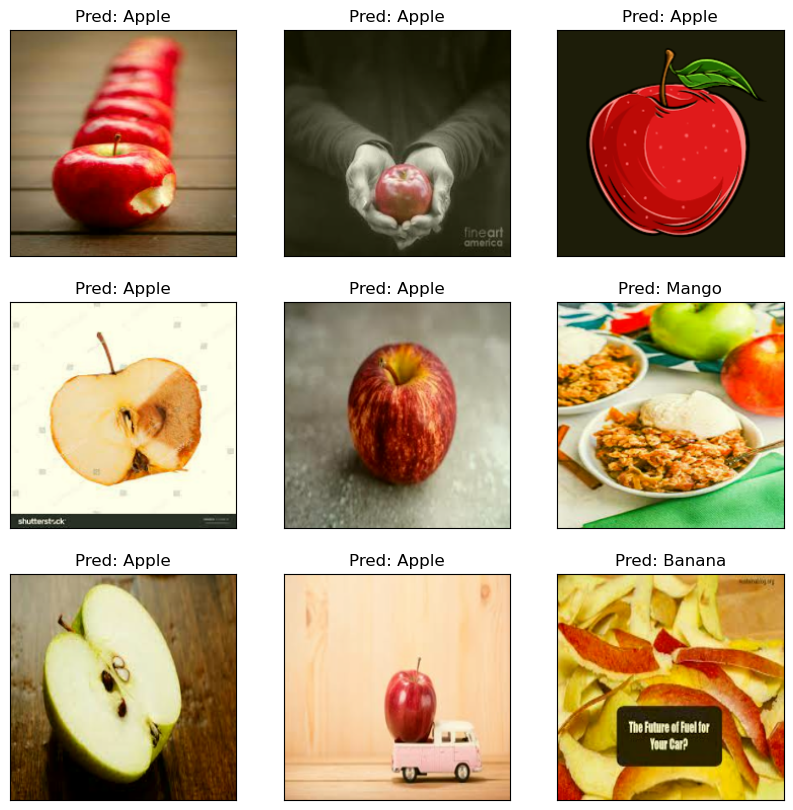

In [29]:
## Train and evaluate the model
train(model,train_loader,criterion,optimizer,epochs=5)
evaluate(model,val_loader,criterion)

visualize_predictions(model,val_loader,transform)
